# Assignment 04: Vehicle Price Prediction

## Aim

To predict vehicle resale price using numerical and categorical vehicle attributes.

## Models

1. Linear Regression
2. Random Forest Regressor
3. Gradient Boosting Regressor

## Evaluation Metrics

- MAE
- RMSE
- R²

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
np.random.seed(42)

n = 600

brands = np.random.choice(
    [
        "Toyota",
        "Honda",
        "Ford",
        "BMW",
        "Hyundai"
    ],
    n,
    p=[
        0.25,
        0.22,
        0.20,
        0.13,
        0.20
    ]
)

brand_premium = {
    "Toyota": 0,
    "Honda": 500,
    "Ford": -500,
    "BMW": 8000,
    "Hyundai": -1000
}

age = np.random.uniform(
    0,
    15,
    n
)

mileage = (
    age
    * np.random.uniform(
        8000,
        16000,
        n
    )
)

engine = np.random.uniform(
    1.0,
    4.0,
    n
)

fuel = np.random.choice(
    [
        "Petrol",
        "Diesel",
        "Electric"
    ],
    n,
    p=[
        0.5,
        0.35,
        0.15
    ]
)

fuel_premium = np.where(
    fuel == "Electric",
    4000,
    np.where(
        fuel == "Diesel",
        800,
        0
    )
)

base_price = (
    28000
    - age * 1400
    - mileage * 0.04
    + engine * 1500
)

price = (
    base_price
    + np.array([
        brand_premium[b]
        for b in brands
    ])
    + fuel_premium
    + np.random.normal(
        0,
        1200,
        n
    )
)

price = np.clip(
    price,
    1500,
    None
)

veh_df = pd.DataFrame({
    "brand": brands,
    "age_years": age,
    "mileage_km": mileage,
    "engine_size_L": engine,
    "fuel_type": fuel,
    "price": price
})

display(
    veh_df.head()
)

,brand,age_years,mileage_km,engine_size_L,fuel_type,price
0,Honda,2.534026,35643.876468,3.869504,Petrol,30602.788570
1,Hyundai,4.178855,34252.801971,3.212525,Petrol,25338.685559
2,BMW,2.655157,21711.190182,2.059754,Petrol,35324.246749
3,Ford,1.330538,14088.909617,1.889607,Petrol,26268.953669
4,Toyota,1.809538,21550.052164,2.049110,Diesel,29932.641937


In [3]:
print("Shape:", veh_df.shape)

print("\nData Types:")
print(veh_df.dtypes)

print("\nSummary:")
display(
    veh_df.describe()
)

Shape: (600, 6)

Data Types:
brand             object
age_years        float64
mileage_km       float64
engine_size_L    float64
fuel_type         object
price            float64
dtype: object

Summary:


,age_years,mileage_km,engine_size_L,price
count,600.000000,600.000000,600.000000,600.000000
mean,7.429401,87965.620524,2.506046,19460.085411
std,4.364389,55058.973795,0.855447,8891.300561
min,0.069480,837.785557,1.004695,1500.000000
25%,3.491592,41344.299818,1.779828,12506.279639
50%,7.504779,82342.731875,2.543861,19810.074330
75%,11.216579,128616.779966,3.238956,26562.137624
max,14.969012,228116.180816,3.995043,40597.959768


In [4]:
num_feats = [
    "age_years",
    "mileage_km",
    "engine_size_L"
]

cat_feats = [
    "brand",
    "fuel_type"
]

In [5]:
preprocess = ColumnTransformer([
    (
        "num",
        StandardScaler(),
        num_feats
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        cat_feats
    )
])

In [6]:
X = veh_df.drop(
    columns=["price"]
)

y = veh_df["price"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(
    "Training samples:",
    len(X_train)
)

print(
    "Testing samples:",
    len(X_test)
)

Training samples: 480
Testing samples: 120


In [8]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=300,
            random_state=42
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            random_state=42
        )
}

In [9]:
results = {}

trained_models = {}

predictions = {}

for name, model in models.items():

    pipe = Pipeline([
        (
            "prep",
            preprocess
        ),
        (
            "model",
            model
        )
    ])

    pipe.fit(
        X_train,
        y_train
    )

    preds = pipe.predict(
        X_test
    )

    results[name] = {

        "MAE":
            mean_absolute_error(
                y_test,
                preds
            ),

        "RMSE":
            mean_squared_error(
                y_test,
                preds
            ) ** 0.5,

        "R2":
            r2_score(
                y_test,
                preds
            )
    }

    trained_models[name] = pipe

    predictions[name] = preds

In [10]:
results_df = pd.DataFrame(
    results
).T

display(
    results_df.round(2)
)

,MAE,RMSE,R2
Linear Regression,935.27,1154.62,0.98
Random Forest,1106.23,1462.22,0.97
Gradient Boosting,1042.51,1323.04,0.98


In [11]:
best_model_name = results_df[
    "RMSE"
].idxmin()

print(
    "Model with lowest RMSE:",
    best_model_name
)

Model with lowest RMSE: Linear Regression


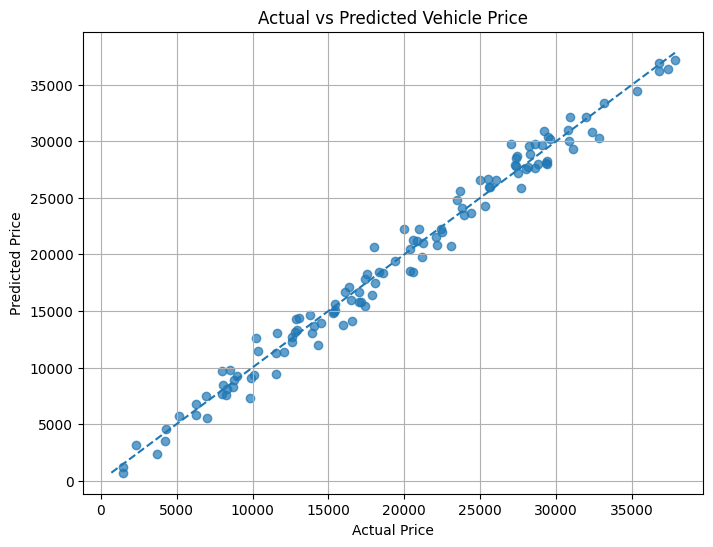

In [12]:
best_preds = predictions[
    best_model_name
]

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    best_preds,
    alpha=0.7
)

min_value = min(
    y_test.min(),
    best_preds.min()
)

max_value = max(
    y_test.max(),
    best_preds.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel(
    "Actual Price"
)

plt.ylabel(
    "Predicted Price"
)

plt.title(
    "Actual vs Predicted Vehicle Price"
)

plt.grid(True)

plt.show()